# A Rota da Neuromante

###### Notebook produzido por Ana Carolina Sayumi I. Alves

## Introdução

Muito embora subestimado - em especial pelos discentes dessa disciplina e de tantas outras ao redor do mundo, os famosos universitários - o _sono_ tem despertado grande interesse científico por seus impactos no bem-estar humano. De acordo com os registros da PubMed, parte da National Library of Medicine - National Center for Biotechnology Information (NCBI), as publicações acerca da qualidade do sono saltaram de 90 para 9713 em 35 anos, como pode ser observado no gráfico abaixo [1].

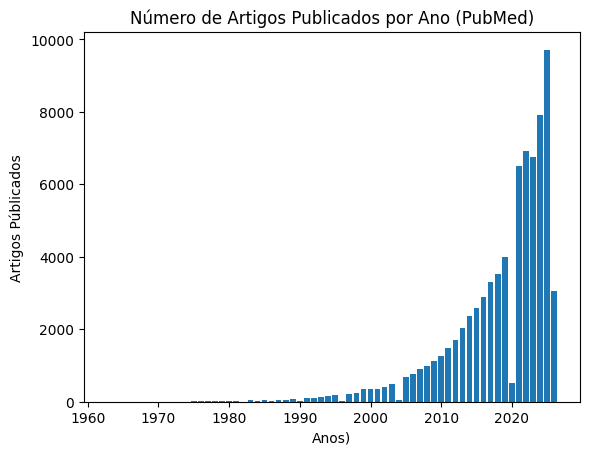

Esse interesse surge, em especial, ao observar a associação entre qualidade do sono e tantos outros aspectos relacionados à saúde: desde regulação emocional à hipertensão [2][3]. Dessa forma, é de grande interesse compreender possíveis padrões entre estilo de vida e a manifestação de distúrbios do sono, parte do trabalho realizado neste notebook, através de modelos de aprendizado de máquina.

### Sobre a atividade

O principal objetivo deste notebook é desenvolver a otimização de uma rede neural do tipo MLP Classificadora. Adicionalmente, foi feita a comparação de seu desempenho com outros modelos, para validação mais robusta de seu desempenho.

Para este estudo o dataset utilizado foi "Sleep Health and Lifestyle Dataset - Unlock sleep insights with the Sleep Health Dataset" [4] publicado na plataforma Kaggle [5][6] por Laksika Tharmalingam. O conjunto de dados escolhido apresenta informações sobre hábitos diários (como número de passos e duração do sono), condições físicas (como pressão sanguínea e índice de massa corporal), características do indivíduo (como idade e ocupação) e a presença de distúrbios do sono. O `target` escolhido foi, justamente, a existência de distúrbios.



Observação: Foi descoberto, tardiamente, que o dataset escolhido é sintético. Não houve justificativa educacional específica para a escolha de um conjunto de dados sintético, além do interesse pessoal da autora pelo assunto e da exploração de MLPs para classificação, somados à coerência do dataset em relação a esses interesses.

## O Código

### Imports

Inicialmente faremos todos os imports necessário para que o código funcione.

In [1]:
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler

import torch
import torch.nn as nn
import torch.optim as optim

import lightning as L
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import cross_val_score
from optuna import create_study
import optuna

import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.dummy import DummyClassifier

from sklearn.metrics import confusion_matrix, classification_report


### Tratamento dos dados

Durante esse processo foi feita a leitura do arquivo original e reorganização dos dados. Foi feito o seguinte, nessa ordem:

- Separação dos dados de pressão sanguínea (do formato p1/p2 para duas colunas p1, p2) *
- Unificação das categorias "Normal" e "Normal Weight" do atributo "BMI Category"
- Transformação de dados ausentes no target para a categoria "Inexistent" **
- Utilização de encoders de acordo com o tipo de dado categórico fornecido ***
- Remoção de dados ausentes ****

*Os dados de pressão sanguínea foram separados e não utilizados como uma razão entre pressões pela perda de informação envolvida nesse processo (a razão entre dois dados de pressão alta pode ser a mesma que a entre dois dados de pressão ideal).

**Essa transformação foi feita sabendo que, no dataset apresentado, os "Nan"s eram, originalmente, a ausência de distúrbios do sono.

***O encoder não foi passado no Target pela forma como o `Pytorch` funciona [7].

****Os dados ausentes foram removidos por último dada a transformação do target.

In [2]:
#Leitura do arquivo
arquivo = "Sleep_health_and_lifestyle_dataset 1.xlsx" 
df = pd.read_excel(arquivo)



#separação de pressão máxima e mínima
df[['BP_max', 'BP_min']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

#Limpeza dos dados
dropar = ['Person ID', 'Blood Pressure']
df = df.drop(dropar, axis=1)



# usando o unique temos
#['Overweight' 'Normal' 'Obese' 'Normal Weight']
#Unindo Normal Weight e Normal em uma única categoria
df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")



#Transformando os NaNs de Sleep Disorder em "Inexistent"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("Inexistent") 



# Separação do target
TARGET = ["Sleep Disorder"]
df_target = df.pop("Sleep Disorder")
df_sem_target = df



#Passando o Label Ecoder no BMI (com ordem)
encoder1 = OrdinalEncoder(categories=[['Normal', 'Overweight', 'Obese']])
df[['BMI Category']] = encoder1.fit_transform(df[['BMI Category']])

#Passando o One-Hot Encoder nos outros dados categóricos
df = pd.get_dummies(df_sem_target, dtype=int)



#Obtenção de atributos
ATRIBUTOS = df.columns.tolist()



#Junção do target ao df novamente
df["Sleep Disorder"] = df_target



#Passando o Label Ecoder no target (sem ordem), mas com categorias definidas para
#não perder informação ao longo do caminho
encoder2 = OrdinalEncoder(categories=[['Inexistent', 'Sleep Apnea', 'Insomnia']])
df[['Sleep Disorder']] = encoder2.fit_transform(df[['Sleep Disorder']])



#Dropna no final para que a classificação de saudável continue no df
df = df.dropna()
df

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,BP_max,BP_min,...,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Sleep Disorder
0,27,6.1,6,42,6,1.0,77,4200,126,83,...,0,0,0,0,0,0,0,1,0,0.0
1,28,6.2,6,60,8,0.0,75,10000,125,80,...,0,0,0,0,0,0,0,0,0,0.0
2,28,6.2,6,60,8,0.0,75,10000,125,80,...,0,0,0,0,0,0,0,0,0,0.0
3,28,5.9,4,30,8,2.0,85,3000,140,90,...,0,0,0,0,1,0,0,0,0,1.0
4,28,5.9,4,30,8,2.0,85,3000,140,90,...,0,0,0,0,1,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,1.0,68,7000,140,95,...,0,0,0,1,0,0,0,0,0,1.0
370,59,8.0,9,75,3,1.0,68,7000,140,95,...,0,0,0,1,0,0,0,0,0,1.0
371,59,8.1,9,75,3,1.0,68,7000,140,95,...,0,0,0,1,0,0,0,0,0,1.0
372,59,8.1,9,75,3,1.0,68,7000,140,95,...,0,0,0,1,0,0,0,0,0,1.0


Uma vez tratado, esse é o dataframe que será utilizado para as próximas etapas.

#### Separação Treino-Validação-Teste

Para uma rede neural do tipo MLP separamos os dados em Treino, Validação e Teste. Isso é feito em razão do passo de validação que é realizado no `lighting`.

Durante o tratamento de dados já obtivemos todos os labels das colunas de atributos e target, conforme segue abaixo.

In [3]:
print(TARGET)
print(ATRIBUTOS)

['Sleep Disorder']
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'BP_max', 'BP_min', 'Gender_Female', 'Gender_Male', 'Occupation_Accountant', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher']


Agora basta fazer a separação pela função já conhecida `train_test_split`.

In [4]:
SEED = 412
TAMANHO_TESTE = 0.1
TAMANHO_VALIDACAO = 0.1

# Divisão dos dados totais em treino e treino+validação
indices = df.index
indices_treino_val, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEED
)

df_treino_val = df.loc[indices_treino_val]
df_teste = df.loc[indices_teste]

# Divisão do treino+validação em treino e validação
indices = df_treino_val.index
indices_treino, indices_val = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEED
)

df_treino = df.loc[indices_treino]
df_val = df.loc[indices_val]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values

X_val = df_val.reindex(ATRIBUTOS, axis=1).values
y_val = df_val.reindex(TARGET, axis=1).values

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values

Aqui vale pontuar que, como o target não é altamente desbalanceado, a divisão entre treino, validação e teste foi feita normalmente, sem divisão proporcinal de categorias.

#### Normalização de atributos

Para um melhor funcionamento de Redes Neurais, é recomendado que os dados de entrada sejam normalizados. Dessa forma, para manter esparcidade, usaremos a normalização por máximo absoluto.

Não usaremos normalizadores no target para não afetar nossa métrica de perda (Cross Entropy Loss) que espera inteiros representando diferentes classes.

In [5]:
normalizador_atributos = MaxAbsScaler()
normalizador_atributos.fit(X_treino)

X_treino_norm = normalizador_atributos.transform(X_treino)
X_val_norm = normalizador_atributos.transform(X_val)
X_teste_norm = normalizador_atributos.transform(X_teste)

### Rede Neural do tipo MLP para um problema de classificação



A referência [8] foi consultada para a construção dessa MLP.

#### Transfomação para tensores

Como vimos, para o Pytorch e Lightning precisamos de dados bidimencionais, dessa forma usaremos a transformação para tensores antes de iniciar nossa arquitetura de rede.

In [1]:
X_treino_norm = torch.tensor(X_treino_norm, dtype=torch.float32)
y_treino = torch.tensor(y_treino, dtype=torch.float32).view(-1, 1)

X_teste_norm = torch.tensor(X_teste_norm, dtype=torch.float32)
y_teste = torch.tensor(y_teste, dtype=torch.float32).view(-1, 1)

X_val_norm = torch.tensor(X_val_norm, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

NameError: name 'torch' is not defined

#### `DataModule`

Aqui vale mencionar que, como toda a divisão de dados foi feita manualmente, usaremos o `DataModule` apenas para que tudo rode como deveria.

In [7]:
class DataModule(L.LightningDataModule):
    def __init__(
        self,
        X_treino, y_treino,
        X_val, y_val,
        X_teste, y_teste,
        batch_size=32,
        num_workers=0
    ):
        super().__init__()

        self.X_treino = X_treino
        self.y_treino = y_treino

        self.X_val = X_val
        self.y_val = y_val

        self.X_teste = X_teste
        self.y_teste = y_teste

        self.batch_size = batch_size
        self.num_workers = num_workers

    def train_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_treino, self.y_treino),
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_val, self.y_val),
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )

    def test_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_teste, self.y_teste),
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )

#### Otimização

O que precisaremos mudar em nossa estrutura para poder fazer a otimização com o optuna é a construção do `self.camadas`, ou seja, o que será recebido no `nn.Sequential`. Como uma MLP é definida, principalmente, por número de camadas, neurônios por camada e função de ativação, é preciso construir nossa classe de modo a sortear valores para cada um desses hiperparâmetros, sendo possível passá-los depois para o Sequential.

O sorteio de valores pelo optuna já nos é familiar, usando a função `trial.suggest`.

Começando pelo número de camadas, como não temos um número fixo, para cada sugestão obtida é necessário um loop que receba esse número de camadas. Nesse loop, sabemos que serão sorteados $n$ neurônios por camada, então é preciso que este trial esteja incluso ali. Mas, uma vez com o número de neurônios de uma camada $n$, é preciso informar a camada seguinte $n+1$ o número que será recebido, então atualizamos dentro do loop qual a entrada. Além disso, precisamos da função de ativação de cada camada, sugerida pelo `trial`. Assim, basta apenas armazenar essas diferentes camadas de modo a desempacotar no nosso `Sequential` e passar a camada de saída - porque sua função de ativação não pode ser randomizada.

Assim, mudamos também os argumentos para instanciar a classe (que agora serão: número de dados de entrada, número de targets e trial do optuna).

In [8]:
class MLP_Class(L.LightningModule):
    def __init__(self, num_dados_entrada, num_targets, trial):
        super().__init__()

        #vai armazenar os dados das camadas
        layers = []

        #para não ter problema atualizando o argumento
        n_entrada = num_dados_entrada

        #sugere o número de camadas
        n_layers = trial.suggest_int("n_layers", 2, 8)

        #loop para atribuir hiperparâmetros a cada camada
        for i in range(n_layers):
            #sugere o número de neurônios - n dados de saida
            n_saida = trial.suggest_int(f"n_neuronios{i}", 4, 30)

            #acrescenta nas camadas a entrada e saída
            layers.append(nn.Linear(n_entrada, n_saida))

            #sorteia a função de ativação a ser acrescentada em seguida
            func_ativação = trial.suggest_categorical(f"f_ativação{i}", ["relu", "gelu"])

            if func_ativação == "relu":
                layers.append(nn.ReLU())
            else:
                layers.append(nn.GELU())

            #atualiza o número de entrada para o número de neuronios sorteados
            #ou seja, a saida da camada passada
            n_entrada = n_saida

        #adiciona a última camada da MLP - pronta para passar na função de perda
        layers.append(nn.Linear(n_entrada, num_targets))

        #operador estrela para desempacotar a lista
        self.camadas = nn.Sequential(*layers)

        #função de perda adequada para classificação
        self.fun_perda = nn.CrossEntropyLoss()

        self.perdas_treino = []
        self.perdas_val = []

        self.curva_aprendizado_treino = []
        self.curva_aprendizado_val = []

    def forward(self, x):
        x = self.camadas(x)
        return x

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y, y_pred)

        self.log("loss", loss, prog_bar=True)
        self.perdas_treino.append(loss)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y, y_pred)

        self.log("val_loss", loss, prog_bar=True)
        self.perdas_val.append(loss)

        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y, y_pred)

        self.log("test_loss", loss)

        return loss

    def on_train_epoch_end(self):
        # Atualiza curva de aprendizado
        perda_media = torch.stack(self.perdas_treino).mean()
        self.curva_aprendizado_treino.append(float(perda_media))
        self.perdas_treino.clear()

    def on_validation_epoch_end(self):
        # Atualiza curva de aprendizado
        perda_media = torch.stack(self.perdas_val).mean()
        self.curva_aprendizado_val.append(float(perda_media))
        self.perdas_val.clear()

Mas por que esses hiperparâmetros e esses ranges?

* O número de camadas controla a complexidade no sentido de não linearidade do nosso modelo, por isso a escolha óbvia como hiperparâmetro. Seu range vai de 2 a 10 para evitar um modelo quase linear, mas também overfitting - dado que não é um dataset muito grande.
* O número de neurônios 



Dito isso, agora faremos a função objetivo do optuna.

In [9]:
MAX_EPOCAS = 40

def funçao_objetivo_MLP(trial):
    dm = DataModule(
        X_treino_norm, y_treino,
        X_val_norm, y_val,
        X_teste_norm, y_teste,
        batch_size=32,
        num_workers=0
    )

    modelo = MLP_Class(num_dados_entrada=len(ATRIBUTOS), num_targets=1, trial=trial)

    treinador = L.Trainer(max_epochs=MAX_EPOCAS)
    treinador.fit(modelo, dm)

    val_perda = treinador.callback_metrics["val_loss"].item()

    return val_perda

Como nossa função objetivo tem apenas o trial como argumento, basta criar o estudo e rodar, sem a necessidade um uma função parcial.

In [10]:
NOME_DO_ESTUDO1 = "MLP_Classifier_SHL_final"

objeto_de_estudo_MLP = create_study(
    direction="minimize",
    study_name=NOME_DO_ESTUDO1,
    storage=f"sqlite:///{NOME_DO_ESTUDO1}.db",
    load_if_exists=True,)

[I 2026-04-07 21:12:31,933] A new study created in RDB with name: MLP_Classifier_SHL_final


In [11]:
N_TENTATIVAS = 100

objeto_de_estudo_MLP.optimize(funçao_objetivo_MLP, n_trials=N_TENTATIVAS, n_jobs=4)

melhor_trial_MLP = objeto_de_estudo_MLP.best_trial
print(f"""O melhor trial foi o {melhor_trial_MLP.number} 
com os seguintes parâmetros: {melhor_trial_MLP.params}""")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, wh

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of tra

Training: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.
[I 2026-04-07 21:32:39,546] Trial 99 finished with value: 0.0 and parameters: {'n_layers': 3, 'n_neuronios0': 14, 'f_ativação0': 'relu', 'n_neuronios1': 5, 'f_ativação1': 'gelu', 'n_neuronios2': 13, 'f_ativação2': 'relu'}. Best is trial 0 with value: 0.0.


O melhor trial foi o 0 
com os seguintes parâmetros: {'n_layers': 7, 'n_neuronios0': 29, 'f_ativação0': 'gelu', 'n_neuronios1': 6, 'f_ativação1': 'gelu', 'n_neuronios2': 18, 'f_ativação2': 'relu', 'n_neuronios3': 4, 'f_ativação3': 'relu', 'n_neuronios4': 5, 'f_ativação4': 'gelu', 'n_neuronios5': 24, 'f_ativação5': 'relu', 'n_neuronios6': 26, 'f_ativação6': 'relu'}


Assim, podemos seguir para o treinamento do modelo final e obtenção de suas métricas - como perda e curva de aprendizado.

In [12]:
melhores_params_MLP = melhor_trial_MLP.params

melhor_trial_formato_trial = optuna.trial.FixedTrial(melhores_params_MLP)

Note que alteramos o formato do melhor_trial para `trial`, uma vez que esse é o tipo de objeto que nossa rede recebe como argumento.

In [13]:
dm = DataModule(
    X_treino_norm, y_treino,
    X_val_norm, y_val,
    X_teste_norm, y_teste,
    batch_size=32,
    num_workers=0
)

modelo_otimizado = MLP_Class(
    num_dados_entrada=len(ATRIBUTOS),
    num_targets=1,
    trial=melhor_trial_formato_trial
)

treinador = L.Trainer(max_epochs=MAX_EPOCAS)

treinador.fit(modelo_otimizado, dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 1.9 K  | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
1.9 K     Trainable params
0         Non-trainable params
1.9 K     Total params
0.008     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.


Feito isso, podemos obter a curva de aprendizado do nosso modelo.

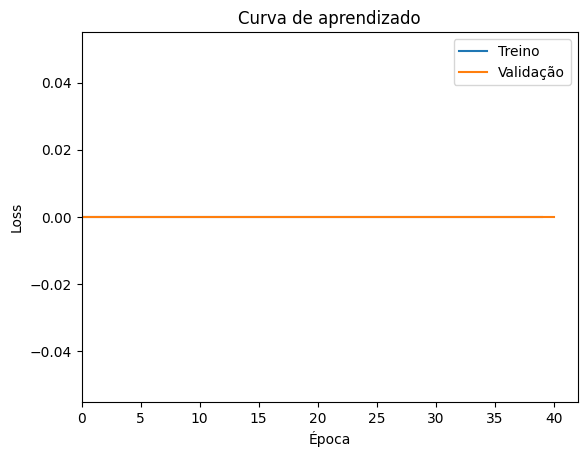

In [14]:
ca_treino = modelo_otimizado.curva_aprendizado_treino
ca_val = modelo_otimizado.curva_aprendizado_val

sns.lineplot(ca_treino, label="Treino")
eixo = sns.lineplot(ca_val, label="Validação")

eixo.set_xlim(left=0)
eixo.set(title="Curva de aprendizado", xlabel="Época", ylabel="Loss");

Essa curva diz muito sobre o que acontece em nosso modelo. Ou temos um grande sobreajuste - o que é possível - ou, ainda mais provável, simplesmente temos um dataset extremamente consistente.

A escolha do dataset sintético provavelmente foi o principal fator para que nossa rede neural tivesse 100% de acerto desde o início - e, portanto uma função de perda igual a 0 desde o início. Esse dataset não apresentou complexidade suficiente para que houvesse aprendizado (o que talvez indique que, para esse problema, estamos matando uma mosca a tiro de canhão). Dessa forma, não há muito o que ser dito a respeito de taxa de aprendizado ou desempenho do modelo, apenas resta questionar a escolha dos dados.

Uma vez com os melhores parâmetros - mesmo que todos tenham apresentado mesmo desempenho - vamos testar esse modelo e avaliá-lo com a métrica de F1-macro.

In [17]:
from sklearn.metrics import f1_score

modelo_otimizado.eval()
dm.setup("test")

with torch.no_grad():
    X_true = dm.X_teste
    y_true = dm.y_teste

    y_pred = modelo_otimizado(X_true)

    #converter pra classes
    y_pred = torch.argmax(y_pred, dim=1)

    #converter pra numpy
    y_pred = y_pred.cpu().numpy()
    y_true = y_true.cpu().numpy()

    F1 = f1_score(y_true, y_pred, average='macro')

    print(f"O F1-macro do modelo MLP Classificador foi de {F1}.")

O F1-macro do modelo MLP Classificador foi de 0.2298850574712644.


In [22]:
print(X_true.shape, y_true.shape, y_pred.shape)
print(y_true[:10])
print(y_pred[:10])
y_lista = y_pred.tolist()
print(y_lista)
print(y_lista.unique())

torch.Size([38, 23]) (38, 1) (38,)
[[1.]
 [0.]
 [2.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [2.]
 [1.]]
[0 0 0 0 0 0 0 0 0 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


AttributeError: 'list' object has no attribute 'unique'

In [16]:
from sklearn.metrics import f1_score

modelo_otimizado.eval()

dm.setup("test")

with torch.no_grad():
    X_true = dm.X_teste

    y_true = dm.y_teste

    y_pred = modelo_otimizado(X_true)

    F1 = f1_score(y_teste, y_pred, average='macro')

    print(f"O F1-macro do modelo MLP Classificador foi de {F1}.")

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

## Conclusão

Otimizar um modelo de rede neural com o optuna não é uma tarefa tão trivial quanto pode parecer de início. Como um parâmetro está diretamente ligado à outro, assim como toda a estrutura da rede (por ser em camadas), deve-se pensar em qual a melhor maneira de sortear os hiperparâmetros e ainda assim construir de maneira coerente sua MLP. 

Pode-se comentar também a escolha de dataset e sua influência direta no resultado da rede neural.

Ademais, há diferenças entre redes classificadoras e redes regressoras, como métrica de perda e funções de ativação, mas, em geral, com a biblioteca `lightning`, o processo é profundamente facilitado.

## Referências

[1] Os dados utilizados podem ser obtidos no seguinte link: https://pubmed.ncbi.nlm.nih.gov/?term=sleep%20quality

[2] RIEMANN, D., et al. Chronic insomnia, REM sleep instability and emotional dysregulation: A pathway to anxiety and depression?, **Journal of Sleep Research**, 34(2), e14252, 2025. DOI: 10.1111/jsr.14252.

[3] Li C, Shang S. Relationship between Sleep and Hypertension: Findings from the NHANES (2007-2014). **Int J Environ Res Public Health**, 18(15):7867, 2021. DOI: 10.3390/ijerph18157867.

[4] THARMALINGAM, L. Sleep Health and Lifestyle Dataset - Unlock sleep insights with the Sleep Health Dataset. Disponível em: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

[5] Acesso em: https://www.kaggle.com/.

[6] Para mais informações à respeito da plataforma: https://en.wikipedia.org/wiki/Kaggle.

[7] Multilayer Perceptron Classification: Pytorch Deep Learning Tutorial - Luke Ditria, minuto 11:17. Disponível em: https://www.youtube.com/watch?v=tJ3-KYMMOOs&t=676s.

[8] Multilayer Perceptron (MLP) with PyTorch Implementation - Rowel Atienza. Disponível em: https://www.youtube.com/watch?v=Rolx9HVmRAc.
